# 02 — Real Data Calibration (AAPL)

This notebook estimates σ, η, γ on AAPL data via yfinance, then computes the optimal trajectory with the calibrated parameters.

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from src.data_fetcher import MarketDataCalibrator, fetch_ohlcv, realized_vol
from src.almgren_chriss import AlmgrenChrissModel
from src.simulator import ExecutionSimulator

plt.rcParams.update({
    'figure.dpi': 72,
    'savefig.dpi': 72,'figure.figsize': (12, 5), 'axes.grid': True, 'grid.alpha': 0.3})
print('✓ Imports OK')

✓ Imports OK


## 1. Fetching and Exploring AAPL Data

In [2]:
TICKER = 'AAPL'
df = fetch_ohlcv(TICKER, period='1y', interval='1d')
print(f'AAPL data — {len(df)} daily bars')
print(f'Period: {df.index[0].date()} → {df.index[-1].date()}')
print()
print(df.tail(5).round(2))

AAPL data — 251 daily bars
Period: 2025-06-02 → 2026-06-01

             close    high     low    open    volume
Date                                                
2026-05-26  308.33  311.82  307.67  309.56  48000500
2026-05-27  310.85  313.26  308.30  308.33  50430900
2026-05-28  312.51  312.80  309.57  310.68  48220400
2026-05-29  312.06  315.00  309.53  311.78  69982800
2026-06-01  306.09  310.93  305.49  309.54  21202563


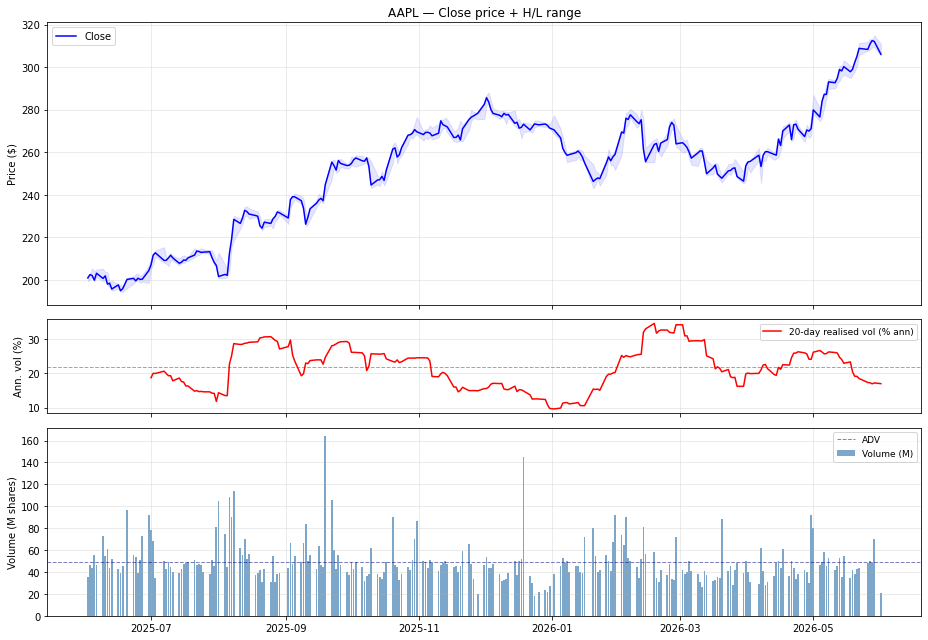

In [3]:
# ── Plot OHLCV ────────────────────────────────────────────────────────────────
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(13, 9), sharex=True,
                                     gridspec_kw={'height_ratios': [3, 1, 2]})

ax1.plot(df.index, df['close'], 'b-', lw=1.5, label='Close')
ax1.fill_between(df.index, df['low'], df['high'], alpha=0.1, color='blue')
ax1.set_ylabel('Price ($)')
ax1.set_title(f'{TICKER} — Close price + H/L range')
ax1.legend()

rv = realized_vol(df['close'], window=20)
ax2.plot(df.index, rv * 100, 'r-', lw=1.5, label='20-day realised vol (% ann)')
ax2.axhline(rv.dropna().mean() * 100, color='r', ls='--', alpha=0.5, lw=1)
ax2.set_ylabel('Ann. vol (%)')
ax2.legend(fontsize=9)

ax3.bar(df.index, df['volume'] / 1e6, color='steelblue', alpha=0.7, label='Volume (M)')
ax3.axhline(df['volume'].mean() / 1e6, color='navy', ls='--', alpha=0.5, lw=1, label='ADV')
ax3.set_ylabel('Volume (M shares)')
ax3.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 2. Calibrating AC Parameters

In [4]:
cal = MarketDataCalibrator(TICKER, period='1y')
params = cal.calibrate(df)   # uses already-downloaded data

print('=' * 50)
print('CALIBRATED PARAMETERS')
print('=' * 50)
print(cal.summary())

CALIBRATED PARAMETERS
Ticker  : AAPL
σ (ann) : 22.10%
σ (day) : 1.3921%
η       : 0.001338
γ       : 2.310639
ADV     : 49,411,024 shares
Spread  : 0.4277%
Price   : $306.09



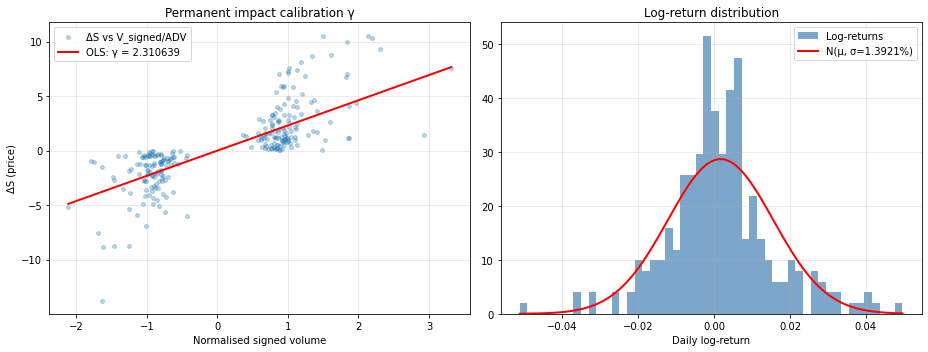

In [5]:
# ── Permanent impact calibration check ─────────────────────────────────────────
prices  = df['close'].values
volumes = df['volume'].values
adv     = params['adv']

delta_S   = np.diff(prices)
V_signed  = volumes[1:] * np.sign(delta_S)
x_norm    = V_signed / adv

# Scatter + regression line
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

ax1.scatter(x_norm, delta_S, alpha=0.3, s=15, label='ΔS vs V_signed/ADV')
x_range = np.linspace(x_norm.min(), x_norm.max(), 100)
ax1.plot(x_range, params['gamma'] * x_range, 'r-', lw=2,
         label=f'OLS: γ = {params["gamma"]:.6f}')
ax1.set_xlabel('Normalised signed volume')
ax1.set_ylabel('ΔS (price)')
ax1.set_title('Permanent impact calibration γ')
ax1.legend()

# Log-returns distribution
log_ret = np.log(prices[1:] / prices[:-1])
ax2.hist(log_ret, bins=50, density=True, alpha=0.7, color='steelblue', label='Log-returns')
from scipy import stats
xr = np.linspace(log_ret.min(), log_ret.max(), 200)
ax2.plot(xr, stats.norm.pdf(xr, log_ret.mean(), log_ret.std()), 'r-', lw=2,
         label=f'N(μ, σ={params["sigma_daily"]:.4%})')
ax2.set_xlabel('Daily log-return')
ax2.set_title('Log-return distribution')
ax2.legend()

plt.tight_layout()
plt.show()

## 3. Optimal Trajectory on Real Parameters

Position: 49,411 shares  (0.100% ADV)
Arrival price: $306.09
Portfolio value: $15,124,213



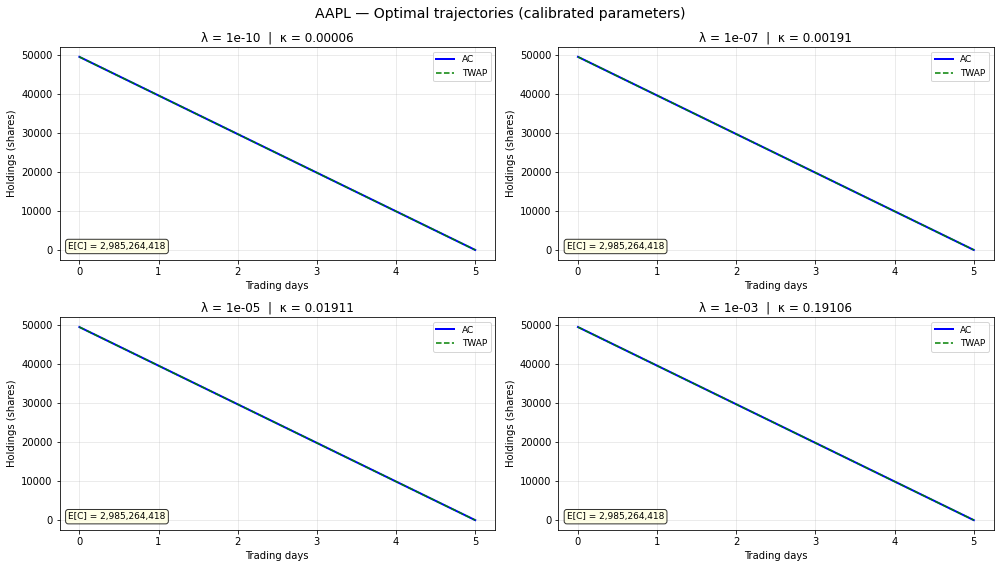

In [6]:
# Position to liquidate: 0.1% of ADV
X_shares = int(0.001 * params['adv'])
T_days   = 5      # 5 trading days
N_steps  = 50

print(f'Position: {X_shares:,} shares  ({X_shares/params["adv"]*100:.3f}% ADV)')
print(f'Arrival price: ${params["price_last"]:.2f}')
print(f'Portfolio value: ${X_shares * params["price_last"]:,.0f}')
print()

LAMBDAS = [1e-10, 1e-7, 1e-5, 1e-3]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

for idx, lam in enumerate(LAMBDAS):
    ax = axes.flat[idx]
    m = AlmgrenChrissModel(
        X=X_shares,
        T=T_days / 252,
        N=N_steps,
        sigma=params['sigma'],
        eta=params['eta'],
        gamma=params['gamma'],
        lam=lam,
    )
    result = m.solve()
    t_days = result.times * 252

    ax.plot(t_days, result.holdings, 'b-', lw=2, label='AC')
    ax.plot(t_days, m.twap_trajectory(), 'g--', lw=1.5, label='TWAP')
    ax.set_xlabel('Trading days')
    ax.set_ylabel('Holdings (shares)')
    ax.set_title(f'λ = {lam:.0e}  |  κ = {m.kappa:.5f}')
    ax.legend(fontsize=9)

    e_cost = result.expected_cost
    ax.text(0.02, 0.05, f'E[C] = {e_cost:,.0f}', transform=ax.transAxes,
            fontsize=9, bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle(f'{TICKER} — Optimal trajectories (calibrated parameters)', fontsize=14)
plt.tight_layout()
plt.show()

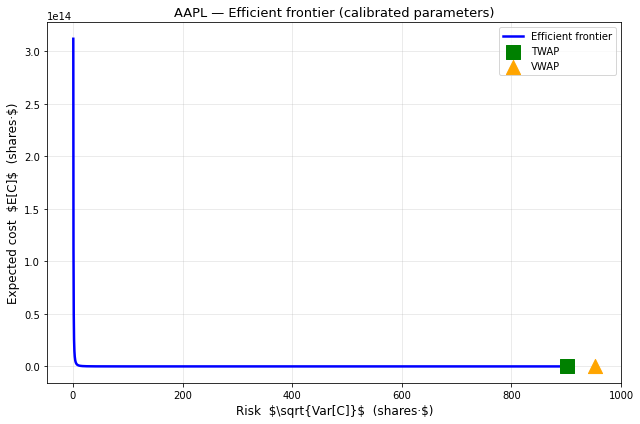

Calibrated parameters summary for AAPL:
  σ annualised : 22.10%
  η (temp)     : 0.00133779
  γ (perm)     : 2.31063897
  ADV          : 49,411,024 shares/day


In [7]:
# Efficient frontier on calibrated parameters
m_cal = AlmgrenChrissModel(
    X=X_shares, T=T_days/252, N=N_steps,
    sigma=params['sigma'], eta=params['eta'], gamma=params['gamma'],
    lam=1e-6,
)
risks_cal, costs_cal = m_cal.efficient_frontier(n_points=300)

e_twap, v_twap = m_cal.cost_from_trajectory(m_cal.twap_trajectory())
e_vwap, v_vwap = m_cal.cost_from_trajectory(m_cal.vwap_trajectory())

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(risks_cal, costs_cal, 'b-', lw=2.5, label='Efficient frontier')
ax.scatter([np.sqrt(v_twap)], [e_twap], s=200, c='green',  marker='s', zorder=6, label='TWAP')
ax.scatter([np.sqrt(v_vwap)], [e_vwap], s=200, c='orange', marker='^', zorder=6, label='VWAP')
ax.set_xlabel('Risk  $\\sqrt{Var[C]}$  (shares·$)', fontsize=12)
ax.set_ylabel('Expected cost  $E[C]$  (shares·$)', fontsize=12)
ax.set_title(f'{TICKER} — Efficient frontier (calibrated parameters)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'Calibrated parameters summary for {TICKER}:')
print(f'  σ annualised : {params["sigma"]:.2%}')
print(f'  η (temp)     : {params["eta"]:.8f}')
print(f'  γ (perm)     : {params["gamma"]:.8f}')
print(f'  ADV          : {params["adv"]:,.0f} shares/day')